
## Level 1 — Task 3: Basic Data Visualization

### Dataset
Stock Prices Dataset

### Focus
Apple Inc. (AAPL)

### Objective
To visualize Apple's historical stock data using line charts,
bar charts, and scatter plots and identify key patterns in opening
and closing prices.

In [1]:
#Importing libraries and load dataset
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns
df = pd.read_csv("../data/2) Stock Prices Data Set.csv")

In [19]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [20]:
df.shape

(497472, 7)

In [21]:
df.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='str')

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 26.6 MB


In [23]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [24]:
df['date']= pd.to_datetime(df['date'])

df['date']

0        2014-01-02
1        2014-01-02
2        2014-01-02
3        2014-01-02
4        2014-01-02
            ...    
497467   2017-12-29
497468   2017-12-29
497469   2017-12-29
497470   2017-12-29
497471   2017-12-29
Name: date, Length: 497472, dtype: datetime64[us]

In [25]:
#Only get apple from the stock
apple = df[df['symbol'] == 'AAPL'].copy()

apple.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


In [26]:
apple.shape

(1007, 7)

In [27]:
apple.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [28]:
apple.duplicated().sum()

np.int64(0)

In [29]:
apple =apple.sort_values('date')

apple.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


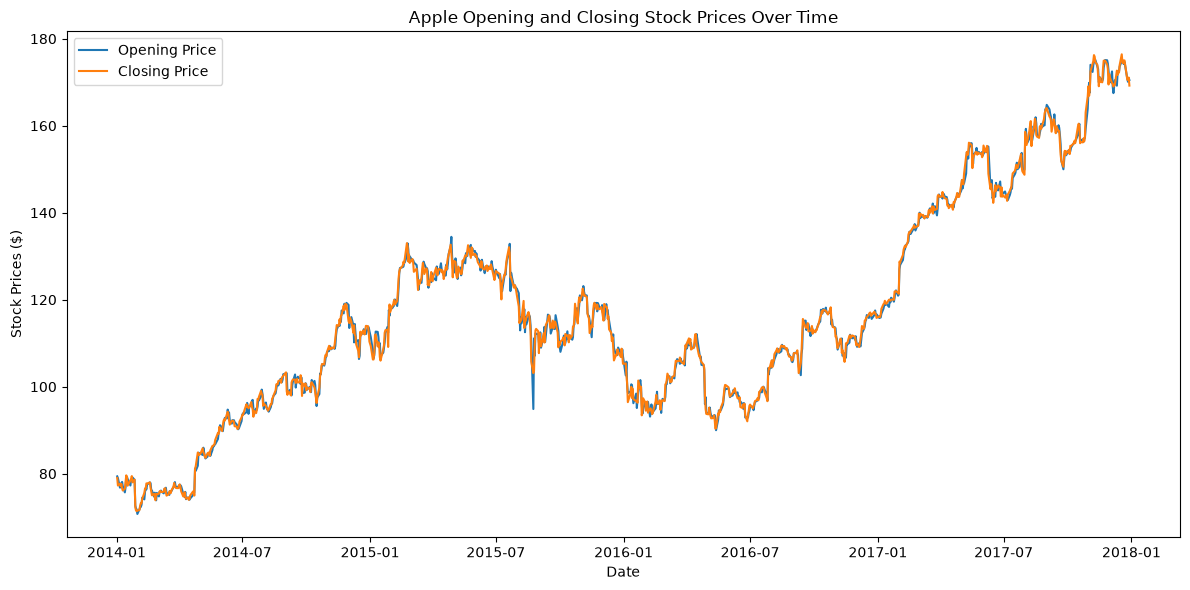

In [30]:
#Line Chart
plt.figure(figsize=(12,6))

plt.plot(apple['date'], apple['open'], label='Opening Price')
plt.plot(apple['date'], apple['close'], label='Closing Price')

plt.title('Apple Opening and Closing Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Prices ($)')
plt.legend()
plt.tight_layout()

plt.savefig("apple_stock_price_trend.png", dpi=300, bbox_inches='tight')

plt.show()

### Key Observation

The line chart shows the Apple's opening and closing stock prices changed
over the observed period. Opening and closing prices generally move
closely together, although daily fluctuations are visible throughout
the time series. Apple stock prices increased substantially across the full 2014–2017 period, despite periods of decline and short-term volatility.

In [31]:
#Bar Chart
#change date to year
apple['year'] = apple['date'].dt.year

#calculate yearly averages
yearly_avg = (
    apple.groupby('year')[['open', 'close']]
    .mean()
    .reset_index()
)

In [32]:
#reshape the data
yearly_avg_long = yearly_avg.melt(
    id_vars='year',
    value_vars=['open', 'close'],
    var_name='Price Type',
    value_name='Average Price'
)

yearly_avg_long['Price Type'] = yearly_avg_long['Price Type'].replace({
    'open': 'Opening Price',
    'close': 'Closing Price'
})

yearly_avg_long

,year,Price Type,Average Price
0,2014,Opening Price,92.219736
1,2015,Opening Price,120.169206
2,2016,Opening Price,104.507698
3,2017,Opening Price,150.482560
4,2014,Closing Price,92.264531
5,2015,Closing Price,120.039861
6,2016,Closing Price,104.604008
7,2017,Closing Price,150.585080


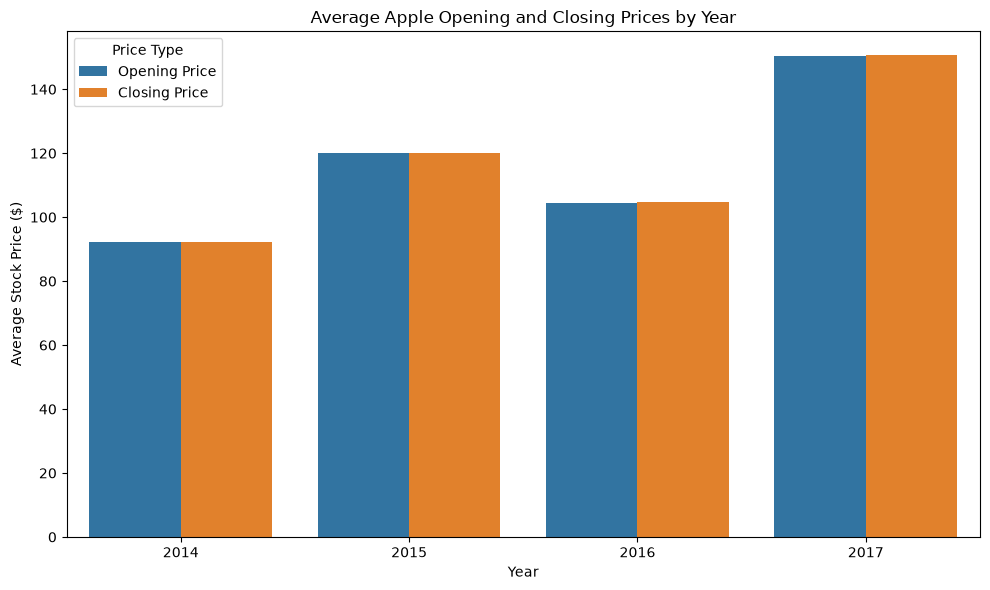

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=yearly_avg_long,
    x='year',
    y='Average Price',
    hue='Price Type'
)

plt.title('Average Apple Opening and Closing Prices by Year')
plt.xlabel('Year')
plt.ylabel('Average Stock Price ($)')
plt.legend(title='Price Type')

plt.tight_layout()

plt.savefig(
    'apple_average_open_close_by_year.png',
    dpi=300,
    bbox_inches='tight')

plt.show()

### Key Observation

The bar chart compares Apple's average opening and closing stock price across
different years. Average opening and closing prices are very similar within each year.
Apple's average stock price increased from 2014 to 2015, declined in 2016,
and then rose substantially in 2017, which had the highest average price
during the observed period.

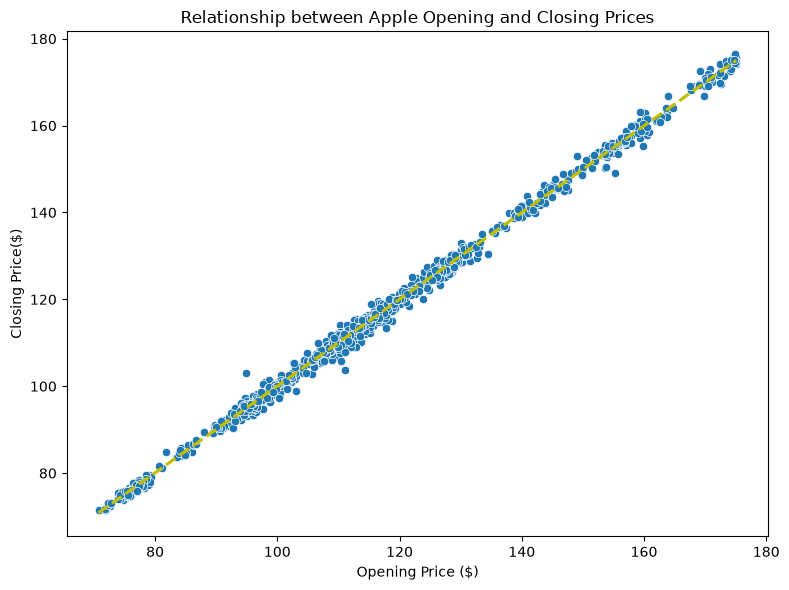

In [34]:
#Scatter Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data= apple,
    x='open',
    y='close'
)

sns.regplot(
    data= apple,
    x= 'open',
    y= 'close',
    scatter= False,
    color = 'y',
    line_kws= {"linestyle": "--"}
)

plt.title("Relationship between Apple Opening and Closing Prices")
plt.xlabel("Opening Price ($)")
plt.ylabel("Closing Price($)")
plt.tight_layout()

plt.savefig("apple_open_vs_close_scatterplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation
The scatter plot shows a strong positive relationship between Apple’s opening and closing prices. 
As the opening price increases, the closing price also increases, and the points are tightly clustered around the trend line.

## Key Findings

- Apple’s opening and closing prices moved very closely together throughout the 2014–2017 period.
- The overall stock price trend increased across the observed period, although there were short-term declines and fluctuations.
- Average opening and closing prices were very similar within each year.
- Average stock prices increased from 2014 to 2015, declined in 2016, and reached their highest yearly average in 2017.
- The scatter plot shows a strong positive relationship between opening and closing prices.

## Conclusion

This project used Matplotlib and Seaborn to visualize Apple stock-price data through line, bar, and scatter charts.

The analysis showed a general increase in Apple’s stock price from 2014 to 2017, while also highlighting short-term volatility. Opening and closing prices moved closely together and showed a strong positive relationship.

Overall, the visualizations demonstrate how different chart types can be used to communicate time trends, yearly comparisons, and relationships between numerical variables.